# 03 静止のまま高さを変える（運動学・S2-A）

## 背景

02 で EqualShare と $\tau=h-J^{\top}F$ により、平地で 5 秒以上ほぼ静止できた。力の和は $mg$ なので、**高さを指定する項が無い**。この段の新しい現象は、関節目標を補間して胴体 $z$ を変えることである（[S2-A](../docs/block-curriculum/02_Stage_Ladder.md)）。予測最適化はまだ無い。

下位の脚力は 02 のまま（EqualShare + $h-J^{\top}F$）。足すのは関節 PD による目標補間だけである。キーフレームへ固定して「立ったことにする」段ではない。高さが 2 つ、それぞれ 5 秒以上保たれること。

### 成功条件（数値。ここが合否）

[README §3.8](../docs/block-curriculum/00_README.md)。**連続 5.0 秒以上、全ステップ。** 一瞬の通過は失敗。2 つの高さの**それぞれ**で 5.0 s 必要。

$z_0$ は走行開始時のベース高さ。$z_{\mathrm{lo}}=z_0-0.03\,\mathrm{m}$。

| 区間 | 量 | 条件 |
|---|---|---|
| 公称 | $\lvert z-z_0\rvert$ | $<0.015\,\mathrm{m}$、連続 $\ge 5.0\,\mathrm{s}$ |
| 低い | $\lvert z-z_{\mathrm{lo}}\rvert$ | $<0.015\,\mathrm{m}$、連続 $\ge 5.0\,\mathrm{s}$ |
| 両区間 | $\lvert\mathrm{roll}\rvert,\lvert\mathrm{pitch}\rvert$ | $<0.10\,\mathrm{rad}$ |
| 両区間 | $\lVert v\rVert$ | $<0.15\,\mathrm{m/s}$ |
| 両区間 | `qpos` | 有限 |
| 結果 | GIF | 1 本以上。指令 GRF と実接触。2 高さが見えること |

満たすまで 04 へ進まない。

## 目的

- 関節目標を home から少ししゃがむ側へ補間し、胴体 $z$ が下がることを見る
- 公称と $-3\,\mathrm{cm}$ 相当を、それぞれ 5 秒以上保持する
- EqualShare の $F_z$ 和は $mg$ のまま（高さの P 制御は次）

## 数式

02 の静止:

$$
\tau_{\mathrm{S1}} = h - J^{\top} F, \quad F_z = mg/4
$$

この段で足す項（運動学）:

$$
\tau = \tau_{\mathrm{S1}} + K_p(q^{des}-q) - K_d \dot q
$$

$q^{des}$ は時間で home としゃがみの間を補間する。$K_p=60\,\mathrm{N\cdot m/rad}$、$K_d=3\,\mathrm{N\cdot m\cdot s/rad}$。

## 図

```
q_des(t):  home --hold 5.5s--> blend 1s --> squat --hold 5.5s
                 |
            S1 + joint PD --> clip --> MuJoCo --> z(t)
```

## 思考過程

02 の力だけでは $z$ の目標が無い。関節を折れば幾何で $z$ が変わる。down キーフレームまで行くと床に近いので、home と down の内分（$a=0.15$）で約 $3\,\mathrm{cm}$ 下げる。

## 仮説

1. S1 だけの 5.5 s では $z$ は $z_0$ 付近のまま（高さ指令が無い）
2. $q^{des}$ をしゃがみへ補間すれば $z$ が $z_0-3\,\mathrm{cm}$ 付近に入り、そこで 5 秒保てる


In [1]:
# --- このセルの意図 ---
# 03 は「関節目標を補間して高さを変える」。脚力は 02 の EqualShare + h-J^T F のまま。
# 合否の数字は背景の表と一致させる。

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display

here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src"))
        break

from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif

# --- 背景の成功条件 ---
HOLD_S = 5.0       # 内容: 各高さで連続 5秒以上
Z_TOL = 0.015      # 内容: |z - z_ref| < 1.5 cm。3cm 差の 2 高さを区別するため 03cm より狭い
ATT_TOL = 0.10     # 内容: |roll|, |pitch| [rad]
V_TOL = 0.15       # 内容: |v| [m/s]
DZ_CMD = 0.03      # 内容: 低い目標は z0 - 3 cm
BLEND_A = 0.15     # 内容: q_low = (1-a)*home + a*down。a=0.15 で約 3 cm 下がる
KP, KD = 60.0, 3.0 # 内容: 関節 PD ゲイン [N·m/rad], [N·m·s/rad]
T_HOLD, T_BLEND = 5.5, 1.0  # 内容: 各高さ 5.5s、その間 1s で qdes を補間

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。一瞬の通過は不合格にするため使う。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best:
            best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 と同じ。モータ範囲外の指令を切る。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def equal_share(mass_kg, n_stance=4):
    """意図: 02 と同じ脚力。この段では Fz を高さ誤差で増減しない（それは 04）。"""
    grf = np.zeros((4, 3))
    grf[:, 2] = mass_kg * 9.81 / n_stance
    return grf

def map_jt(model, data, geom_ids, grf):
    """内容: tau_map = -J^T F の関節 12 成分 [N·m]。"""
    tau_full = np.zeros(model.nv)
    for geom_id, force in zip(geom_ids, grf):
        J = np.zeros((3, model.nv))
        mujoco.mj_jacGeom(model, data, J, None, int(geom_id))  # 内容: 足 geom の並進ヤコビ
        tau_full -= J.T @ force
    return tau_full[-model.nu:]

def tau_s1(plant, geoms, cmd):
    """意図: 02 の静止トルク。関節 PD は含まない。
    内容: h + (-J^T F)。h は qfrc_bias の関節成分。"""
    h = np.asarray(plant.data.qfrc_bias[-plant.model.nu:], dtype=np.float64)
    return h + map_jt(plant.model, plant.data, geoms, cmd)

plant0 = MujocoGo2(scene="flat", seed=0)
dt = plant0.sim_dt
n_hold = int(round(T_HOLD / dt))    # 内容: 5.5s の step 数
n_blend = int(round(T_BLEND / dt))  # 内容: 1s の step 数
q_home = np.asarray(plant0.data.qpos[7:], dtype=np.float64)  # 内容: 初期 12 関節 [rad]
q_down = np.asarray(plant0.model.key("down").qpos[7:], dtype=np.float64)  # 内容: 伏せキーフレーム（使い切らない）
q_low = (1.0 - BLEND_A) * q_home + BLEND_A * q_down  # 内容: 少ししゃがんだ目標関節
print("dt", dt, "n_hold", n_hold, "n_blend", n_blend)
print("q_home thigh,calf", q_home[1], q_home[2], "q_low", q_low[1], q_low[2])


dt 0.002 n_hold 2750 n_blend 500
q_home thigh,calf 0.9 -1.8 q_low 0.9465 -1.9491


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


## 試行 1 — S1 だけの 5.5 s（仮説 1）

高さ指令も関節補間も無し。$z$ は $z_0$ 付近に留まる、というのが次の補間を足す理由である。


In [2]:
# --- このセルの意図 ---
# 試行 1: 02 の S1 だけ。高さ指令も関節補間も無し。
# z が z0 付近のまま、が「力の和 mg では高さを指定できない」の確認。03 合格ではない。

p = MujocoGo2(scene="flat", seed=0)
geoms = p.foot_geom_ids()
cmd = equal_share(p.mass_kg)  # 内容: 一定 mg/4
z0 = float(p.base_pos()[2])   # 内容: この走行の公称高さ
ok = []
zs = []
for _ in range(n_hold):
    u = clip_torque(tau_s1(p, geoms, cmd), p.model.actuator_ctrlrange)
    p.step(u)
    z = float(p.base_pos()[2])
    rpy = p.base_rpy()
    v = float(np.linalg.norm(p.base_lin_vel_world()))
    # 意図: 公称高さの表で 5秒持てるか（持てる。ただし高さは変わらない）
    ok.append(
        abs(z - z0) < Z_TOL
        and abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL
        and v < V_TOL and bool(np.isfinite(p.data.qpos).all())
    )
    zs.append(z)
hold = longest_true_seconds(ok, dt)
zs = np.asarray(zs)
print("trial1 S1-only  z0", z0, "zT", zs[-1], "dz max", np.max(np.abs(zs - z0)), "hold_s", hold)
print("trial1: height did not change (expected). This is not 03 pass yet.")


trial1 S1-only  z0 0.29017051033281377 zT 0.2899433500997583 dz max 0.0010384496506857244 hold_s 5.5
trial1: height did not change (expected). This is not 03 pass yet.


## 試行 2 — 関節補間で 2 高さ（仮説 2）

公称 5.5 s → 1 s で $q^{des}$ をしゃがみへ → しゃがみ 5.5 s。各高さで背景の表を数値確認する。


In [3]:
# --- このセルの意図 ---
# 試行 2: S1 に関節 PD を足し、qdes を home → しゃがみへ補間する。
# 公称 5.5s と低い 5.5s のそれぞれで、背景の表が連続 5秒 True なら合格。

def qdes_at_step(k):
    """内容: ステップ番号 k だけの目標関節。高さ P は使わない。
    前半 home、1s 線形補間、後半 q_low。"""
    if k < n_hold:
        return q_home
    if k < n_hold + n_blend:
        s = (k - n_hold) / n_blend  # 内容: 0→1。補間の進み
        return (1.0 - s) * q_home + s * q_low
    return q_low

def tau_s2a(plant, geoms, cmd, qdes):
    """内容: tau = S1 + Kp(qdes-q) - Kd qd。新しい項は関節 PD だけ。"""
    q = np.asarray(plant.data.qpos[7:], dtype=np.float64)   # 内容: 今の 12 関節 [rad]
    qd = np.asarray(plant.data.qvel[6:], dtype=np.float64)  # 内容: 今の関節速度 [rad/s]
    u = tau_s1(plant, geoms, cmd) + KP * (qdes - q) - KD * qd
    return clip_torque(u, plant.model.actuator_ctrlrange)

p = MujocoGo2(scene="flat", seed=0)
geoms = p.foot_geom_ids()
cmd = equal_share(p.mass_kg)
z0 = float(p.base_pos()[2])
z_lo = z0 - DZ_CMD  # 内容: 背景の低い目標 z0-3cm
n_total = n_hold + n_blend + n_hold  # 内容: 5.5 + 1 + 5.5 s
ok_hi, ok_lo = [], []  # 内容: 公称区間・低い区間それぞれの True/False
zs = []
for k in range(n_total):
    p.step(tau_s2a(p, geoms, cmd, qdes_at_step(k)))
    z = float(p.base_pos()[2])
    rpy = p.base_rpy()
    v = float(np.linalg.norm(p.base_lin_vel_world()))
    att = abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL and v < V_TOL and bool(np.isfinite(p.data.qpos).all())
    zs.append(z)
    if k < n_hold:
        ok_hi.append(att and abs(z - z0) < Z_TOL)  # 意図: 公称にいるか
    if k >= n_hold + n_blend:
        ok_lo.append(att and abs(z - z_lo) < Z_TOL)  # 意図: 低い目標にいるか（補間中は見ない）

hold_hi = longest_true_seconds(ok_hi, dt)
hold_lo = longest_true_seconds(ok_lo, dt)
zs = np.asarray(zs)
print("z0", z0, "z_lo target", z_lo)
print("hold_hi_s", hold_hi, "hold_lo_s", hold_lo)
print("z end-hi", zs[n_hold - 1], "z start-lo", zs[n_hold + n_blend], "z end", zs[-1])
assert hold_hi >= HOLD_S, f"nominal height held {hold_hi:.3f}s < {HOLD_S}"
assert hold_lo >= HOLD_S, f"low height held {hold_lo:.3f}s < {HOLD_S}"
print("03 PASS: two heights held", hold_hi, "s and", hold_lo, "s")


z0 0.29017051033281377 z_lo target 0.2601705103328138
hold_hi_s 5.5 hold_lo_s 5.5
z end-hi 0.28849454564235055 z start-lo 0.2669802342966643 z end 0.26280183318112327
03 PASS: two heights held 5.5 s and 5.5 s


## 結果（走行）

GIF は公称保持 → 補間 → 低い保持。白は指令 GRF（EqualShare）、色は実接触。


/home/takuya/work/mpc_dog/notebook/assets/03_height_kinematic.gif 3254537 bytes t 12.002000000000677


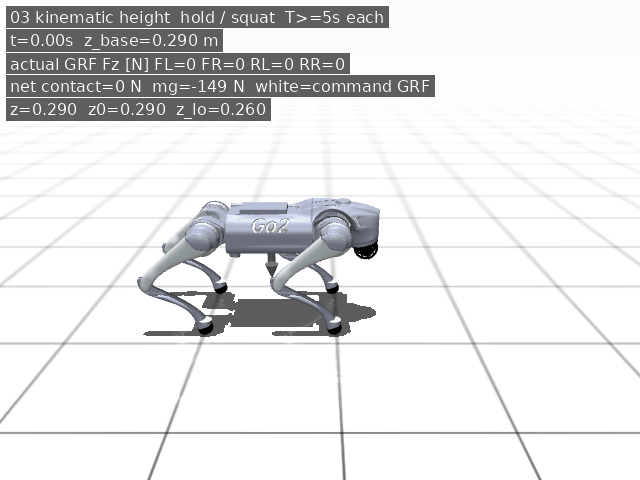

In [4]:
# --- このセルの意図 ---
# 試行 2 と同じ制御・同じ時間で GIF を残す。seed を揃えて数値ログと映像を対応させる。

step_k = {"i": 0}  # 内容: GIF ループのステップ番号。tau_fn は plant しか受け取らないので外に持つ

def tau_fn(plant):
    # 内容: 上の qdes_at_step(k) と同じ時刻表でトルクを出す
    u = tau_s2a(plant, geoms, cmd, qdes_at_step(step_k["i"]))
    step_k["i"] += 1
    return u

plant = MujocoGo2(scene="flat", seed=0)
gif = Path("assets/03_height_kinematic.gif")
path = render_rollout_gif(
    plant,
    gif,
    n_steps=n_total,       # 内容: 公称+補間+低い、全部
    capture_every=80,      # 意図: 間引き
    tau_fn=tau_fn,
    command_grf=cmd,       # 内容: 白矢印=一定の EqualShare（高さ P ではない）
    extra_lines=lambda pl: [f"z={pl.base_pos()[2]:.3f}  z0={z0:.3f}  z_lo={z_lo:.3f}"],
    title="03 kinematic height  hold / squat  T>=5s each",
)
print(path.resolve(), path.stat().st_size, "bytes", "t", float(plant.data.time))
display(Image(filename=str(path)))


## 分析

- 試行 1: S1 だけでは $z$ が公称のまま。高さの目標が力に無いことの確認
- 試行 2: 関節補間で $z$ が $z_0-3\,\mathrm{cm}$ 付近へ入り、背景の 5 秒条件を両方満たした
- EqualShare の $F_z$ 和は $mg$ のまま。高さ P はまだ足していない

## 次の仮説

力側で $z^{ref}$ を追う（$F_z$ 合計を $mg+k_p(z^{ref}-z)$ にする）と、関節目標無しでも高さが動くか。それが S2-B である。
